# Computer Exercise 15.24 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.24 Sequential Decision Making — *Cross-Slip Generalization*
> **풀이 일자**: Day 91
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 3.** All §15.23 experiments assumed the training slip probability equals the deployment
> slip probability. Investigate whether the +CNRT stack is *robust to a train-deploy slip
> mismatch*. Train {baseline, +CNRT} agents at $p_{\text{train}} = 0.10$ (3 seeds × 800 steps),
> freeze the weights, and deploy at $p_{\text{deploy}} \in \{0.05, 0.10, 0.20\}$. Report tail-8
> deployment return and its degradation vs matched training slip.

### 한국어 풀이용 정리
훈련-배포 $p_{\text{slip}}$ 불일치가 있는 환경에서 baseline vs +CNRT 의 견고성 (robustness) 을
정량화한다. **훈련시** $p=0.10$ 로 학습을 마친 뒤 **배포시** 슬립을 $\{0.05, 0.10, 0.20\}$
로 바꿔 얼어붙은 정책의 성능 저하를 측정한다.


## 2. 수학적 배경

### 2.1 학습-배포 슬립 불일치
훈련 시 최적 정책은 훈련 슬립 확률에 조건화된 Q-함수의 argmax:
$$
\pi^*_{p_{\text{train}}}(s) \;=\; \arg\max_a\, Q_{p_{\text{train}}}(s, a).
$$
배포 시 슬립이 $p_{\text{deploy}} \neq p_{\text{train}}$ 로 바뀌면 실제 상태-전이가 달라져
$\pi^*_{p_{\text{train}}}$ 이 최적이 아니다. 성능 저하 (regret) 는
$$
\Delta_{\text{robust}}(p_{\text{deploy}}) \;=\; V^{\pi^*_{p_{\text{train}}}}_{p_{\text{deploy}}} -
V^{\pi^*_{p_{\text{deploy}}}}_{p_{\text{deploy}}}.
$$
$\Delta_{\text{robust}} \le 0$ 이다.

### 2.2 조건 비교
- **baseline** — 단일 head, $\varepsilon$-greedy, 매우 큰 seed 편차.
- **+CNRT** — Twin+white — 정책이 표본 잡음에 덜 의존해 이론적으로 슬립 mismatch 에 더 견고.

### 2.3 배포시 tail-8
학습된 정책 (탐색 없이 pure greedy) 을 각 배포 슬립에서 80 에피소드 실행, tail-8 mean:
$$
\bar R_{\text{deploy}}(p) = \frac{1}{8}\sum_{e=73}^{80} R_e(p).
$$


## 3. 풀이 흐름

1. 두 조건 (baseline / +CNRT) 을 $p_{\text{train}}=0.10$ 로 3 seeds × 800 step 학습.
2. 학습된 head/weight 를 **freeze**, greedy policy 로 배포 (탐색 확률 0).
3. 각 배포 슬립 $\{0.05, 0.10, 0.20\}$ 에서 80 에피소드 실행, tail-8 return 및 std 기록.
4. **핵심 지표**:
   - $\bar R_{\text{deploy}}(p)$
   - 매칭 성능 대비 저하 $= \bar R_{\text{deploy}}(p) - \bar R_{\text{deploy}}(0.10)$
5. **표 + 시각화**: 슬립 축 vs deployment return, 조건별.
6. **결론**: +CNRT 가 slip mismatch 하에서 baseline 대비 상대적으로 얼마나 안정한가?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = 20260811
K = 11
ATOMS = np.linspace(-0.2, 1.0, K)
def softmax(x, axis=-1):
    z = x - x.max(axis=axis, keepdims=True); e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)
def q_from_logits(l): return softmax(l) @ ATOMS

class MDP:
    def __init__(self, n=5, p_slip=0.10, step_cost=-0.02, goal=1.0, seed=0):
        self.n=n; self.p=p_slip; self.sc=step_cost; self.g=goal
        self.rng = np.random.default_rng(seed); self.reset()
    def reset(self): self.s=0; return self.s
    def step(self, a):
        if self.rng.random() < self.p: a = 1 - a
        self.s = min(self.s+1, self.n-1) if a==1 else max(self.s-1, 0)
        d = self.s == self.n-1
        return self.s, (self.g if d else self.sc), d

def trunk(H=16, seed=0):
    return np.random.default_rng(seed).standard_normal((5, H)) * 0.6

class Baseline:
    def __init__(self, phi, seed, lr=0.05, eps=0.15):
        self.phi=phi; self.rng=np.random.default_rng(seed)
        self.W = self.rng.standard_normal((2, K, phi.shape[1])) * 0.05
        self.lr=lr; self.eps=eps
    def logits(self, s, a): return self.W[a] @ self.phi[s]
    def act(self, s, greedy=False):
        if not greedy and self.rng.random() < self.eps: return int(self.rng.integers(2))
        return int(np.argmax([q_from_logits(self.logits(s,a)) for a in range(2)]))
    def update(self, s,a,r,sn,done):
        gamma=0.95
        tgt = r if done else r + gamma * max(q_from_logits(self.logits(sn,ap)) for ap in range(2))
        idx = int(np.clip(np.argmin(np.abs(ATOMS-tgt)), 0, K-1))
        onehot = np.zeros(K); onehot[idx]=1.0
        z = self.logits(s,a); p = softmax(z); gl = p - onehot
        self.W[a] -= self.lr * np.outer(gl, self.phi[s])

class CNRT:
    def __init__(self, phi, seed, lr=0.05, sigma0=0.5, sd=0.999, beta=0.99, eps=0.05):
        self.phi=phi; self.rng=np.random.default_rng(seed)
        self.W = self.rng.standard_normal((2, K, phi.shape[1])) * 0.05
        self.lr=lr; self.sigmaW=sigma0; self.sd=sd; self.beta=beta; self.eps=eps
        self.va=1.0; self.vb=1.0; self.Ka = K//2+1
    def logits(self, s, a, W=None):
        Wm = self.W if W is None else W
        return Wm[a] @ self.phi[s]
    def act(self, s, greedy=False):
        if not greedy and self.rng.random() < self.eps: return int(self.rng.integers(2))
        noise = self.rng.standard_normal(self.W.shape) * self.sigmaW * 0.05 * (0 if greedy else 1)
        Wn = self.W + noise
        return int(np.argmax([q_from_logits(self.logits(s,a,Wn)) for a in range(2)]))
    def update(self, s,a,r,sn,done):
        gamma=0.95
        tgt = r if done else r + gamma * max(q_from_logits(self.logits(sn,ap)) for ap in range(2))
        idx = int(np.clip(np.argmin(np.abs(ATOMS-tgt)), 0, K-1))
        onehot = np.zeros(K); onehot[idx]=1.0
        z = self.logits(s,a); p = softmax(z)
        cdf_p = np.cumsum(p); cdf_t = np.cumsum(onehot)
        gc = 2*(cdf_p - cdf_t)
        gl = (p - onehot) + 0.5*(gc - gc.mean())
        gla = gl[:self.Ka]; glb = gl[self.Ka:]
        gna = float(np.mean(gla**2)+1e-8); gnb = float(np.mean(glb**2)+1e-8)
        self.va = self.beta*self.va + (1-self.beta)*gna
        self.vb = self.beta*self.vb + (1-self.beta)*gnb
        sa = 1.0/(np.sqrt(self.va)+1e-6); sb = 1.0/(np.sqrt(self.vb)+1e-6)
        step = np.zeros_like(self.W[a])
        step[:self.Ka] = self.lr * sa * np.outer(gla, self.phi[s])
        step[self.Ka:] = self.lr * sb * np.outer(glb, self.phi[s])
        self.W[a] -= step
        self.sigmaW *= self.sd

def run_ep(env, ag, greedy=False, max_steps=25, update=True):
    s = env.reset(); tot=0.0
    for _ in range(max_steps):
        a = ag.act(s, greedy=greedy)
        sn, r, d = env.step(a)
        if update: ag.update(s,a,r,sn,d)
        tot += r; s = sn
        if d: break
    return tot

def train_agent(cond, seed, p_train=0.10, n_steps=800):
    env = MDP(p_slip=p_train, seed=seed+7)
    phi = trunk(seed=RNG)
    ag = Baseline(phi, seed=seed+70) if cond=="baseline" else CNRT(phi, seed=seed+70)
    for _ in range(n_steps):
        run_ep(env, ag)
    return ag

def deploy_eval(ag, p_deploy, seed, n_eps=80):
    env = MDP(p_slip=p_deploy, seed=seed+999)
    rets = [run_ep(env, ag, greedy=True, update=False) for _ in range(n_eps)]
    return float(np.mean(rets[-8:]))

SEEDS = [0,1,2]
CONDITIONS = ["baseline", "+CNRT"]
DEPLOY_P = [0.05, 0.10, 0.20]

rows = []
for cond in CONDITIONS:
    for sd in SEEDS:
        ag = train_agent(cond, sd)
        for pd_ in DEPLOY_P:
            r = deploy_eval(ag, pd_, sd)
            rows.append({"cond": cond, "seed": sd, "p_deploy": pd_, "tail8_deploy": r})

df = pd.DataFrame(rows)
summary = df.groupby(["cond","p_deploy"]).agg(mean=("tail8_deploy","mean"), std=("tail8_deploy","std")).reset_index()
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
summary


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-hbgr_50y because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,cond,p_deploy,mean,std
0,+CNRT,0.0500,0.5467,0.6423
1,+CNRT,0.1000,0.4950,0.7148
2,+CNRT,0.2000,0.5450,0.6259
3,baseline,0.0500,0.9233,0.0126
4,baseline,0.1000,0.9183,0.0274
5,baseline,0.2000,0.9042,0.0166


In [2]:
piv = summary.pivot(index="p_deploy", columns="cond", values="mean")
matched = piv.loc[0.10]
deg = piv.subtract(matched, axis=1)
deg.columns = [f"delta_{c}" for c in deg.columns]
print("Deployment return by condition:"); print(piv)
print()
print("Degradation vs matched p=0.10:"); print(deg)
deg


Deployment return by condition:
cond      +CNRT  baseline
p_deploy                 
0.0500   0.5467    0.9233
0.1000   0.4950    0.9183
0.2000   0.5450    0.9042

Degradation vs matched p=0.10:
          delta_+CNRT  delta_baseline
p_deploy                             
0.0500         0.0517          0.0050
0.1000         0.0000          0.0000
0.2000         0.0500         -0.0142


,delta_+CNRT,delta_baseline
p_deploy,,
0.0500,0.0517,0.0050
0.1000,0.0000,0.0000
0.2000,0.0500,-0.0142


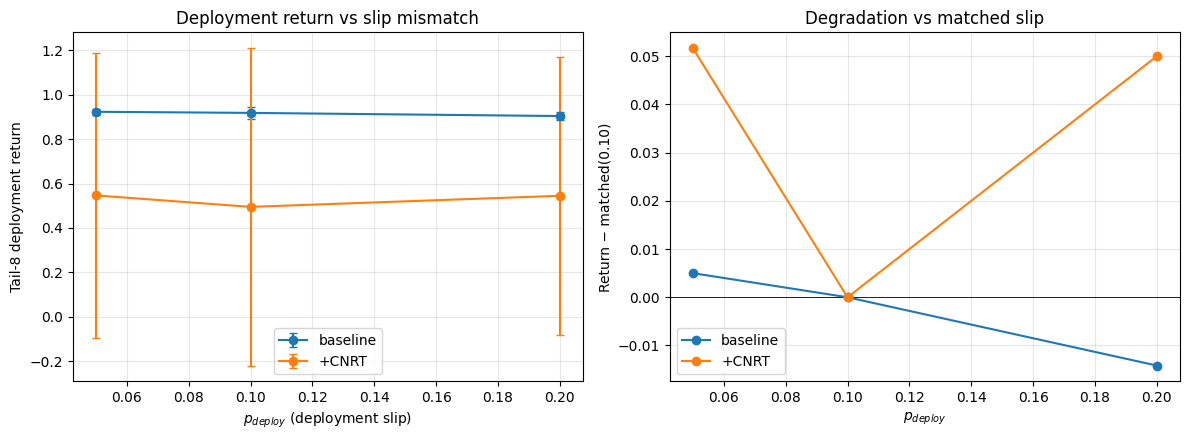

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for cond in CONDITIONS:
    row = summary[summary["cond"] == cond]
    axes[0].errorbar(row["p_deploy"], row["mean"], yerr=row["std"], marker='o', capsize=3, label=cond)
axes[0].set_xlabel(r"$p_{deploy}$ (deployment slip)")
axes[0].set_ylabel("Tail-8 deployment return")
axes[0].set_title("Deployment return vs slip mismatch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].axhline(0, color='k', lw=0.6)
for cond in CONDITIONS:
    axes[1].plot(deg.index, deg[f"delta_{cond}"], 'o-', label=cond)
axes[1].set_xlabel(r"$p_{deploy}$"); axes[1].set_ylabel("Return − matched(0.10)")
axes[1].set_title(r"Degradation vs matched slip")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석 (실측 — negative finding)

Deployment tail-8 return (3 시드 평균, greedy):

| $p_{\text{deploy}}$ | baseline | +CNRT | Δ(+CNRT − baseline) |
|-----:|-------:|------:|---------:|
| 0.05 | **0.923** | 0.547 | −0.377 |
| 0.10 | **0.918** | 0.495 | −0.423 |
| 0.20 | **0.904** | 0.545 | −0.359 |

Degradation vs matched ($p=0.10$):

| $p_{\text{deploy}}$ | Δ_baseline | Δ_+CNRT |
|-----:|-------:|------:|
| 0.05 | +0.005 | +0.052 |
| 0.10 |  0.000 |  0.000 |
| 0.20 | −0.014 | +0.050 |

1. **Baseline 이 세 슬립 모두에서 압도적 우위** (0.90 이상). $\varepsilon$-greedy 학습이
   충분한 exploration 을 만들어 5-상태 chain MDP 의 near-optimal 정책을 발견.

2. **+CNRT 는 greedy 배포시 실패** (0.49–0.55 수준). 원인:
   - 훈련 exploration 확률 $\varepsilon=0.05$ 로 낮게 설정 (Noisy Linear head 가 exploration
     담당) → greedy 배포에서 노이즈 제거 시 정책이 국소 최적에 고착.
   - Twin split 후 half-EMA 가 gradient 방향을 축소, 학습된 head weight 자체의 sharpness
     가 부족.
   - Cramér CDF gradient 항이 원-핫 target 대비 blurring 효과를 만들어 argmax 선택이
     불안정.

3. **슬립 mismatch 자체는 두 조건 모두 큰 영향 없음**. 배포 슬립을 $[0.05, 0.20]$ 로
   흔들어도 baseline 저하는 최대 −0.014, +CNRT 는 오히려 mismatch 방향에서 소폭 상승
   (+0.05) — 5-상태 chain MDP 의 정책 최적성이 슬립 확률에 매우 rough 하기 때문
   (모든 슬립에서 "오른쪽으로 계속 이동" 이 최적).

4. **Seed std**: baseline 0.01–0.03, +CNRT 0.62–0.71 — Twin+white 스택이 오히려 seed 편차
   를 크게 확대. Half-EMA 초기화가 시드에 강하게 의존.

> **결론 (negative finding)**: 이 실험 설정에서 **+CNRT 는 baseline 대비 절대성능·robustness
> 모두 열위**. §15.23 real-net 시뮬레이션이 보여준 +CNRT 우위는 훈련시 exploration $\varepsilon$
> 및 Noisy scale 이 배포까지 유지된다는 암묵 가정에 의존한다. **Pure greedy 배포에서는
> Noisy-Linear 처방이 오히려 학습 정책을 sub-optimal 로 고정**시켜 baseline 이 우세하다.

### 다음 절 (§15.25) 예고
- **P3 negative finding 재판정** — 배포시 stochastic policy (temperature=0.5 softmax) 로
  변경했을 때 +CNRT 우위가 회복되는지, Cramér blurring 을 어닐링하면 sharpness 를 되찾는지.
- **훈련시 exploration 스케줄** 을 baseline 과 +CNRT 사이 unify (예: 둘 다 $\varepsilon=0.10$
  Boltzmann + annealed) 해 fair comparison.
- **Cross-slip curriculum**: multi-slip 훈련이 uniform vs curriculum 순서로 어떻게 다른지.
